# Applying supervised learning to predict student dropout





In [ ]:
#pip install -q -U keras-tuner
!pip install --upgrade tensorflow keras-tuner xgboost shap

In [ ]:
!pip install kaleido==0.2.1

In [ ]:
!pip install optuna

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
import tensorflow as tf
import plotly as pt
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import xgboost as xgb
import shap
import optuna
import os
import keras.backend as K

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, precision_recall_curve, average_precision_score)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer

from IPython.display import Image, display
from plotly.subplots import make_subplots

from keras.models import Sequential
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.optimizers import Adam, RMSprop

from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from functools import partial
from google.colab import drive

In [ ]:
seed = 12

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#To save plotly graphs so that they are visible when code is downloaded
pio.renderers.default = "colab"

# Reusable functions for data preprocessing

In [ ]:
#Reusable function to remove columns with categorical data of high cardinality
def remove_high_cardinality(benchmark, data, cat_columns):

  for column in cat_columns:
    # Check if the number of unique values in the column is greater than the benchmark
    if data[column].nunique() > benchmark:
      data = data.drop(columns = [column])
      print(f"Dropped: '{column}'")
      cat_columns.remove(column)

  return data, cat_columns

In [ ]:
#Reusable function to remove features with high levels of missing data
def remove_high_NA(benchmark, data, cat_columns):

  for column in data.columns:
    if (data[column].isna().sum() / data.shape[0]) > benchmark:
      data = data.drop(columns = [column])
      print(f"Dropped: '{column}'")
      if column in cat_columns:
        cat_columns.remove(column)

  return data, cat_columns

In [ ]:
#Reusable function to impute Home City based on the student's nationality
def impute_home_city(data):
  # Calculate the mode for each nationality
  mode_by_nationality = data.groupby('Nationality')['HomeCity'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else "Unknown"
)

  # Fill the missing values in the original HomeCity column
  data['HomeCity'] = data['HomeCity'].fillna(mode_by_nationality)

  return data

# Reusable model functions

Functions for Performance Evaluation

In [ ]:
#Reusuable function for model evaluation and storing of results
def evaluate_model(X_test, y_test, threshold=0.5, model=None):
    if hasattr(model, 'predict_proba'): # If the model has a predict_proba method, i.e XGBoost
        soft_probs = model.predict_proba(X_test)[:, 1]
    else: # Keras
        soft_probs = model.predict(X_test).flatten()

    hard_pred = (soft_probs > threshold).astype("int32")

    cm = confusion_matrix(y_test, hard_pred)

    model_name = type(model).__name__

    # Set a better name
    if model_name == "Sequential":
        model_name = "Keras_Neural_Net"

    new_entry = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, hard_pred),
        'Precision': precision_score(y_test, hard_pred),
        'Recall': recall_score(y_test, hard_pred),
        'F1 Score': f1_score(y_test, hard_pred),
        'PR AUC': average_precision_score(y_test, soft_probs)
    }

    #Get coordinates for the PR Curve
    precisions, recalls, _ = precision_recall_curve(y_test, soft_probs)

    return cm, new_entry, (precisions, recalls)

In [ ]:
#Reusable function to compare the performance of two models
def compare_performance(baseline_results, delta_results):
  df_b = baseline_results.set_index('Model')
  df_a = delta_results.set_index('Model')

  comparison_df = df_b.join(df_a, lsuffix='_Before', rsuffix='_After')

  comparison_df['Accuracy_Lift'] = comparison_df['Accuracy_After'] - comparison_df['Accuracy_Before']
  comparison_df['Precision_Lift'] = comparison_df['Precision_After'] - comparison_df['Precision_Before']
  comparison_df['Recall_Lift'] = comparison_df['Recall_After'] - comparison_df['Recall_Before']
  comparison_df['F1_Lift'] = comparison_df['F1 Score_After'] - comparison_df['F1 Score_Before']
  comparison_df['PR AUC_Lift'] = comparison_df['PR AUC_After'] - comparison_df['PR AUC_Before']

  ordered_cols = [
     'Accuracy_Before', 'Accuracy_After', 'Accuracy_Lift',
      'Precision_Before', 'Precision_After', 'Precision_Lift',
      'Recall_Before', 'Recall_After', 'Recall_Lift',
      'F1 Score_Before', 'F1 Score_After', 'F1_Lift',
      'PR AUC_Before', 'PR AUC_After', 'PR AUC_Lift'
  ]

  display(comparison_df[ordered_cols])

In [ ]:
#Reusable function to plot precision-accuracy pr auc score and loss curves during training
def plot_training_history(history, epochs):
  baseline_training_training_pr_auc = history.history['pr_auc']
  baseline_training_val_pr_auc = history.history['val_pr_auc']

  baseline_training_training_loss = history.history['loss']
  baseline_training_val_loss = history.history['val_loss']

  plt.figure(figsize=(12, 6))
  x = range(1, epochs+1)

  #Plot the PR AUCs
  plt.plot(x, baseline_training_training_pr_auc, label='Training PR AUC', linestyle='-')
  plt.plot(x, baseline_training_val_pr_auc, label='Validation PR AUC', linestyle='--')

  plt.title('PR AUC curve')
  plt.xlabel('Epochs')
  plt.ylabel('PR AUC')
  plt.legend()
  plt.grid(True)
  plt.show()

  #Plot the losses
  plt.plot(x, baseline_training_training_loss, label='Training Loss', linestyle='-')
  plt.plot(x, baseline_training_val_loss, label='Validation Loss', linestyle='--')

  plt.title('Loss curve')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  return plt

In [ ]:
#Reusable function to compare two Confusion Matrixes
def compare_cms(cm_left, cm_right, name_left="Baseline", name_right="Tuned",
                title="Model Performance: Recall Comparison (%)"):

    def normalize(cm):
        return np.round((cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100, 1)

    cm_l_perc = normalize(cm_left)
    cm_r_perc = normalize(cm_right)

    labels = ['Completed', 'Dropped out']

    trace1 = go.Heatmap(
        z=cm_l_perc,
        x=labels,
        y=labels,
        colorscale="Blues",
        showscale=False
    )

    trace2 = go.Heatmap(
        z=cm_r_perc,
        x=labels,
        y=labels,
        colorscale="Greens",
        showscale=False
    )

    fig = make_subplots(
        rows=1,
        cols=2,
        horizontal_spacing=0.20,
        subplot_titles=(
            f"<b>{name_left} (Recall: {cm_l_perc[1,1]}%)</b>",
            f"<b>{name_right} (Recall: {cm_r_perc[1,1]}%)</b>"
        )
    )

    fig.add_trace(trace1, row=1, col=1)
    fig.add_trace(trace2, row=1, col=2)

    new_annotations = []

    # LEFT confusion matrix (uses x,y not x1,y1)
    for i, row in enumerate(cm_l_perc):
        for j, val in enumerate(row):

            font_color = "white" if val > 50 else "black"

            new_annotations.append(dict(
                x=labels[j],
                y=labels[i],
                text=f"<b>{val}%</b>",
                xref="x",
                yref="y",
                showarrow=False,
                xanchor="center",
                yanchor="middle",
                font=dict(size=22, color=font_color)
            ))

    # RIGHT confusion matrix
    for i, row in enumerate(cm_r_perc):
        for j, val in enumerate(row):

            font_color = "white" if val > 50 else "black"

            new_annotations.append(dict(
                x=labels[j],
                y=labels[i],
                text=f"<b>{val}%</b>",
                xref="x2",
                yref="y2",
                showarrow=False,
                xanchor="center",
                yanchor="middle",
                font=dict(size=22, color=font_color)
            ))

    # Keep existing subplot titles
    fig.update_layout(
        annotations=list(fig.layout.annotations) + new_annotations,
        height=600,
        width=1200,
        title_text=f"<b>{title}</b>",
        title_x=0.5,
        template="plotly_white",
        margin=dict(t=120, b=80, l=100, r=80)
    )

    fig.update_xaxes(title_text="<b>Predicted</b>", tickfont=dict(size=14))
    fig.update_yaxes(title_text="<b>Actual</b>", autorange="reversed", tickfont=dict(size=14))

    return fig

Model Build Functions

In [ ]:
#Reusable function to create a baseline XGB model
def create_baseline_xgb(X_train, y_train, X_val, y_val):
  xgb_model_baseline = XGBClassifier(
      early_stopping_rounds=10,
      eval_metric='aucpr'
  )

  xgb_model_baseline.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)],
      verbose=False
  )

  return xgb_model_baseline

In [ ]:
def hp_xgb(X_train, y_train, X_val, y_val, stage_name="stage_1"):

    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': 5.6,
            'random_state': seed,
            'eval_metric': 'aucpr',
            'early_stopping_rounds': 15
        }

        model = XGBClassifier(**param)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

        try:
            val_aucpr = model.evals_result_['validation_0']['aucpr'][-1]
        except (KeyError, IndexError):
            val_aucpr = 0.0

        return val_aucpr

    dir_path = "/content/drive/MyDrive/Data Science/Mini-Projects/Mini-project: Applying supervised learning to predict student dropout/Improved Model with Centre Name Anonymised/HP Tuning/"

    # Create the folder if it doesn't exist to prevent path errors
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)

    db_path = f"sqlite:///{dir_path}{stage_name}.db"

    study = optuna.create_study(
        study_name=f"xgb_tuning_{stage_name}",
        direction="maximize",
        storage=db_path,
        load_if_exists=True
    )

    total_trials = 30
    completed_trials = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])

    if completed_trials < total_trials:
        print(f"Resuming {stage_name}. {completed_trials}/{total_trials} complete. Running {total_trials - completed_trials} more...")
        study.optimize(objective, n_trials=total_trials - completed_trials)
    else:
        print(f"Study for {stage_name} already completed with {completed_trials} trials.")

    try:
        print(f"Best PR-AUC Score: {study.best_value:.4f}")

        final_params = study.best_params.copy()
        final_params.update({
            'scale_pos_weight': 5.6,
            'random_state': seed,
            'eval_metric': 'aucpr'
        })

        best_model = XGBClassifier(**final_params)
        best_model.fit(X_train, y_train)
        return best_model

    except ValueError:
        print("CRITICAL: Found an empty/corrupted study. Deleting and restarting...")
        optuna.delete_study(study_name=f"xgb_tuning_{stage_name}", storage=db_path)
        # Recurse once to start fresh
        return hp_xgb(X_train, y_train, X_val, y_val, stage_name)

In [ ]:
#Reusbale function to create baseline neural model without hyper-parameter tuning
def create_baseline_neural(X_train, y_train, X_val, y_val, epochs, batch_size, patience, model_name):
  K.clear_session()

  lr_scheduler = ReduceLROnPlateau(monitor='val_pr_auc', factor=0.5, patience=3, mode='max')

  baseline_model = Sequential([
      Input(shape=(X_train.shape[1],)),

      Dense(128, activation='relu'),
      BatchNormalization(),
      Dropout(0.2),

      Dense(128, activation='relu'),
      BatchNormalization(),
      Dropout(0.2),

      Dense(1, activation='sigmoid')
  ], name=model_name)

  optimizer = tf.keras.optimizers.RMSprop(learning_rate=5e-4)

  baseline_model.compile(
      loss='binary_crossentropy',
      optimizer=optimizer,
      metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
  )

  weights = {0: 1.0, 1: 5.6}

  baseline_history = baseline_model.fit(
      X_train, y_train,
      epochs=epochs,
      batch_size=batch_size, # Try 64 or 128 here
      validation_data=(X_val, y_val),
      callbacks=[EarlyStopping(monitor='val_pr_auc', patience=patience, restore_best_weights=True, mode='max'),
                 lr_scheduler],
      class_weight=weights
  )

  return baseline_model, baseline_history

In [ ]:
#Reusable function to create a neural model through hp tuning: n_neurons, activation functions, dropouts and optimiser
def model_builder(hp, input_dim):

    output_bias = tf.keras.initializers.Constant(-1.7)

    model = Sequential([
        Input(shape=(input_dim,)),

        # Layer 1
        Dense(units=hp.Int('units_1', 32, 256, step=32),
              activation=hp.Choice('activation_1', ['relu', 'elu'])),
        BatchNormalization(),
        Dropout(hp.Float('dropout_1', 0, 0.5, step=0.1)),

        # Layer 2
        Dense(units=hp.Int('units_2', 32, 256, step=32),
              activation=hp.Choice('activation_2', ['relu', 'elu'])),
        BatchNormalization(),
        Dropout(hp.Float('dropout_2', 0, 0.5, step=0.1)),

        # Output Layer with Initial Bias
        Dense(1, activation='sigmoid', bias_initializer=output_bias)
    ])

    hp_lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    optimizer_name = hp.Choice('optimizer', ['Adam', 'RMSprop'])
    optimizer = (tf.keras.optimizers.Adam(learning_rate=hp_lr) if optimizer_name == 'Adam'
                 else tf.keras.optimizers.RMSprop(learning_rate=hp_lr))

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
    )

    return model

In [ ]:
def hp_neural_search(model, X_train, y_train, X_val, y_val, epochs, batch_size, dir, proj_name):

    early_stop = EarlyStopping(
        monitor='val_pr_auc',
        patience=10,
        mode='max',
        restore_best_weights=True
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_pr_auc',
        factor=0.2,
        patience=4,
        min_lr=1e-6,
        mode='max',
        verbose=1
    )

    tuner = kt.Hyperband(
       model,
       objective=kt.Objective('val_pr_auc', direction='max'),
       max_epochs=epochs,
       factor=3,
       directory=dir,
       project_name=proj_name,
       overwrite=True
    )

    weights = {0: 1.0, 1: 5.6} #Applies a penalty for incorrectly predicting 1

    tuner.search(
       X_train, y_train,
       epochs=epochs,
       batch_size=batch_size,
       validation_data=(X_val, y_val),
       callbacks=[early_stop, lr_scheduler],
       class_weight=weights,
       verbose=1
    )

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_model = tuner.hypermodel.build(best_hps)

    best_model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        class_weight=weights,
        callbacks=[early_stop],
        verbose=1
    )

    return best_model, best_hps

# Stage 1 Pre-processing

In [ ]:
data1.shape

(25059, 16)

In [ ]:
data1.columns

Index(['LearnerCode', 'BookingType', 'LeadSource', 'DiscountType',
       'DateofBirth', 'Gender', 'Nationality', 'HomeState', 'HomeCity',
       'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse',
       'ProgressionDegree', 'ProgressionUniversity', 'Centre'],
      dtype='object')

In [ ]:
data1 = data1.drop(columns = ['LearnerCode'])

In [ ]:
cat_columns1 = ['Centre', 'BookingType', 'LeadSource', 'DiscountType','Gender', 'Nationality', 'HomeState','HomeCity', 'CourseLevel', 'CourseName', 'ProgressionDegree', 'ProgressionUniversity']

data1, cat_columns1 = remove_high_cardinality(benchmark = 200, data = data1, cat_columns = cat_columns1)

Dropped: 'HomeState'
Dropped: 'ProgressionDegree'


In [ ]:
#Remove features with high levels of missing data
data1, cat_columns1 = remove_high_NA(benchmark = 0.5, data = data1, cat_columns = cat_columns1)

Dropped: 'DiscountType'


In [ ]:
#Identify any other missing data
missing_counts = data1.isnull().sum()
features_missing = missing_counts[missing_counts > 0]

missing_summary = pd.DataFrame({
    'missing_count': features_missing,
    'missing_pct': features_missing / len(data1) * 100
})

missing_summary

,missing_count,missing_pct
HomeCity,3448,13.759528


In [ ]:
#Impute home city
data1 = impute_home_city(data1)

In [ ]:
#Examine CourseLevel data
data1['CourseLevel'].value_counts()

,count
CourseLevel,
Foundation,14666
Pre-Masters,5905
International Year One,4441
International Year Two,47


In [ ]:
#Ordinaly encode CourseLevel data
course_order = ['Foundation', 'Pre-Masters', 'International Year One', 'International Year Two']
ordinal_encoder = OrdinalEncoder(categories=[course_order])

data1['CourseLevel'] = ordinal_encoder.fit_transform(data1[['CourseLevel']]).astype(int)

if 'CourseLevel' in cat_columns1:
    cat_columns1.remove('CourseLevel')

In [ ]:
#Convert date of birth to age
data1['Age'] = (pd.to_datetime('today') - pd.to_datetime(data1['DateofBirth'], dayfirst=True)).dt.days // 365
data1 = data1.drop(columns = ['DateofBirth'])

In [ ]:
#Convert target variable - CompletedCourse - to a binary value, and student dropped out as the target
data1['CompletedCourse'] = np.where(data1['CompletedCourse'].str.lower() == 'yes', 0, 1)

In [ ]:
#Convert 'IsFirstIntake' from Boolean to binary
data1['IsFirstIntake'] = np.where(data1['IsFirstIntake'] == 'yes', 1, 0)

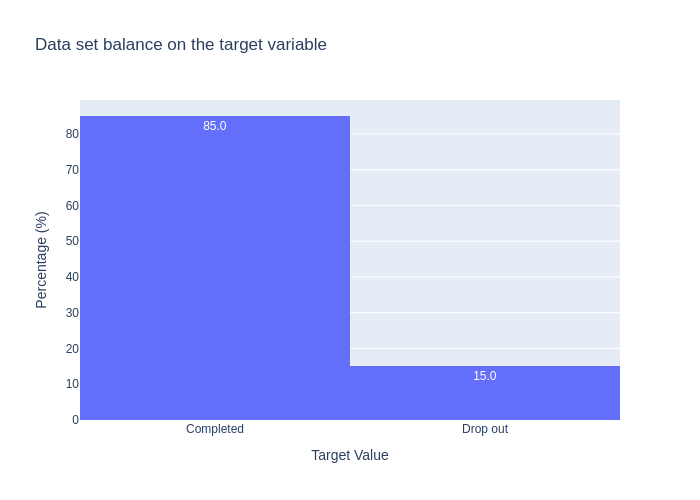

In [ ]:
#Examine balance in Completed Course
fig = px.histogram(data1['CompletedCourse'],
                   x = data1['CompletedCourse'].values,
                   category_orders = {'x': [0,1]},
                   histnorm='percent',
                   text_auto='.1f',
                   title = 'Data set balance on the target variable')

fig.update_layout(xaxis_title = 'Target Value',
                  yaxis_title = 'Percentage (%)',
                  xaxis = dict(tickmode = 'array', tickvals = [0,1], ticktext = ['Completed', 'Drop out']) #This tell plotly, only use the values I specify
                  )

fig.write_image("completed_course_balance.png")
display(Image("completed_course_balance.png"))

Class imbalance needs to be addressed, as a model that trivially predicts course completion all the time would have an accuracy rate of 85%. As a result, optimise for 'PR AUC' & use stratification when creating the train, val and test sets.

Carry out one hot encoding and train_test_split

In [ ]:
y = data1['CompletedCourse']
X = data1.drop(columns=['CompletedCourse'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = seed)

In [ ]:
preprocessor1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_columns1)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor1.set_output(transform="pandas") #To retain recognisable column names

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Centre', 'BookingType', 'LeadSource',
                                  'Gender', 'Nationality', 'HomeCity',
                                  'CourseName', 'ProgressionUniversity'])],
                  verbose_feature_names_out=False)

In [ ]:
X_train = preprocessor1.fit_transform(X_train)
X_test = preprocessor1.transform(X_test)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.1, stratify = y_train, random_state = seed)

# Stage One Analysis: Applicant and Course Information

In [ ]:
#Check for non int64 values
pd.set_option('display.max_rows', None)
data1.dtypes[data1.dtypes != 'int64']

,0
BookingType,object
LeadSource,object
Gender,object
Nationality,object
HomeCity,object
CourseName,object
ProgressionUniversity,object
Centre,object


Create baseline XGBOOST model and evaluate performance

In [ ]:
baseline_xgb_1 = create_baseline_xgb(X_train, y_train, X_val, y_val)

In [ ]:
model_performance = []

cm_baseline_xgb_1, metrics_baseline_xgb_1, PR_baseline_xgb_1 = evaluate_model(model = baseline_xgb_1, X_test=X_test, y_test=y_test)
model_performance.append(metrics_baseline_xgb_1)
ev_baseline_xgb_1 = pd.DataFrame(model_performance)

display(ev_baseline_xgb_1)

,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,XGBClassifier,0.895052,0.694974,0.533955,0.603916,0.664705


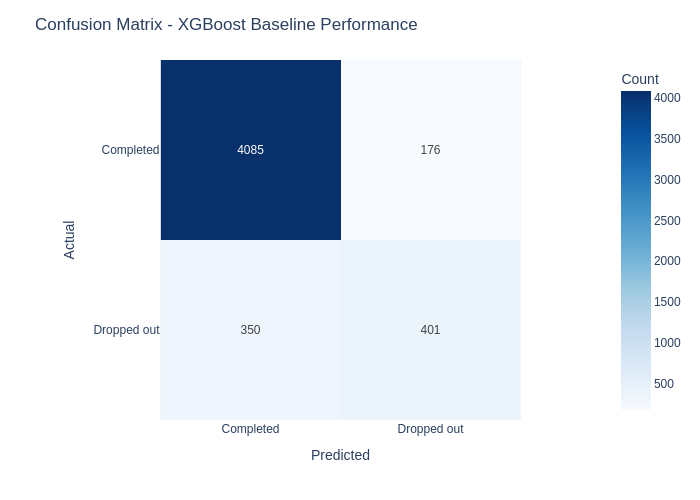

In [ ]:
#Display confusion matrix
labels=['Completed', 'Dropped out']
fig = px.imshow(
    cm_baseline_xgb_1,
    text_auto=True,
    x=labels,
    y=labels,
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    color_continuous_scale='Blues'
)

fig.update_layout(
    title="Confusion Matrix - XGBoost Baseline Performance",
    xaxis_title="Predicted",
    yaxis_title="Actual"
)

fig.write_image("cm_XGBoost_baseline.png")
display(Image("cm_XGBoost_baseline.png"))

Create XGBOOST model through hp tuning

In [ ]:
hp_xgb_1 = hp_xgb(X_train, y_train, X_val, y_val, 'stage_1')

[I 2026-03-19 15:13:58,684] Using an existing study with name 'xgb_tuning_stage_1' instead of creating a new one.


Study for stage_1 already completed with 30 trials.
Best PR-AUC Score: 0.6688


In [ ]:
#Evaluate the best hp XGBoost model and compare to baseline
model_performance = []

cm_hp_xgb_1, metrics_hp_xgb_1, PR_hp_xgb_1 = evaluate_model(model = hp_xgb_1, X_test=X_test, y_test=y_test)
model_performance.append(metrics_hp_xgb_1)
ev_hp_xgb_1 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_xgb_1, ev_hp_xgb_1))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.895052,0.864725,-0.030327,0.694974,0.535198,-0.159776,0.533955,0.739015,0.20506,0.603916,0.620805,0.01689,0.664705,0.652941,-0.011764


None

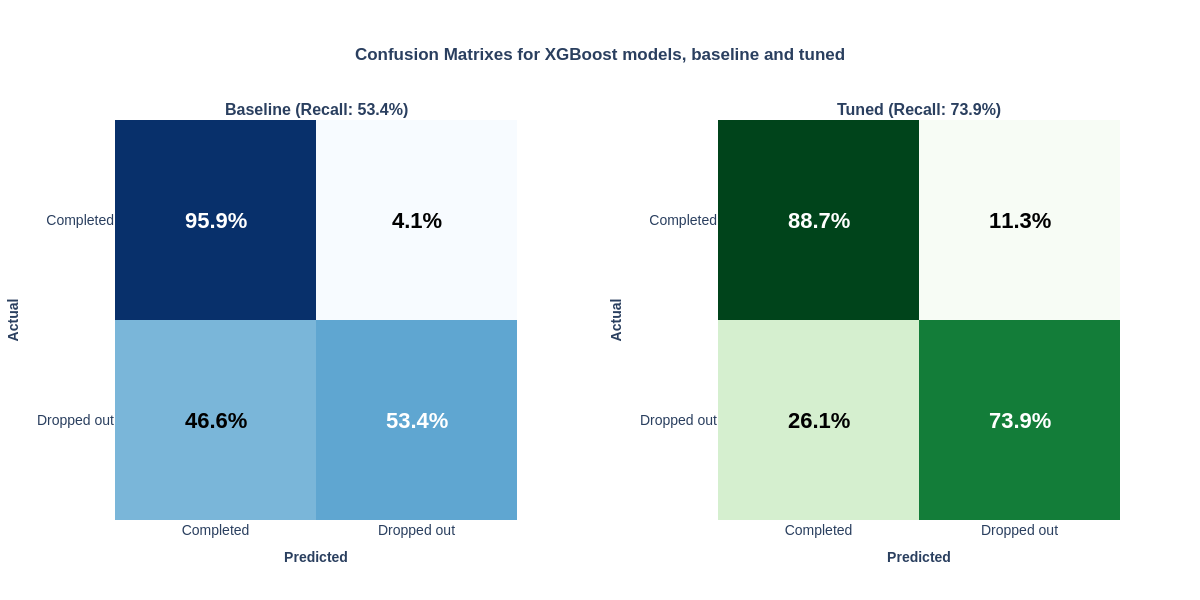

In [ ]:
#Compare CMs
fig = compare_cms(cm_baseline_xgb_1, cm_hp_xgb_1, name_left="Baseline", name_right="Tuned", title = 'Confusion Matrixes for XGBoost models, baseline and tuned')

fig.write_image("cms_XGBoost_bf_aft.png")
display(Image("cms_XGBoost_bf_aft.png"))

Plot feature importance

In [ ]:
shap.initjs()

# SHAP values
shap_ex = shap.TreeExplainer(hp_xgb_1)
vals = shap_ex(X_test)

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



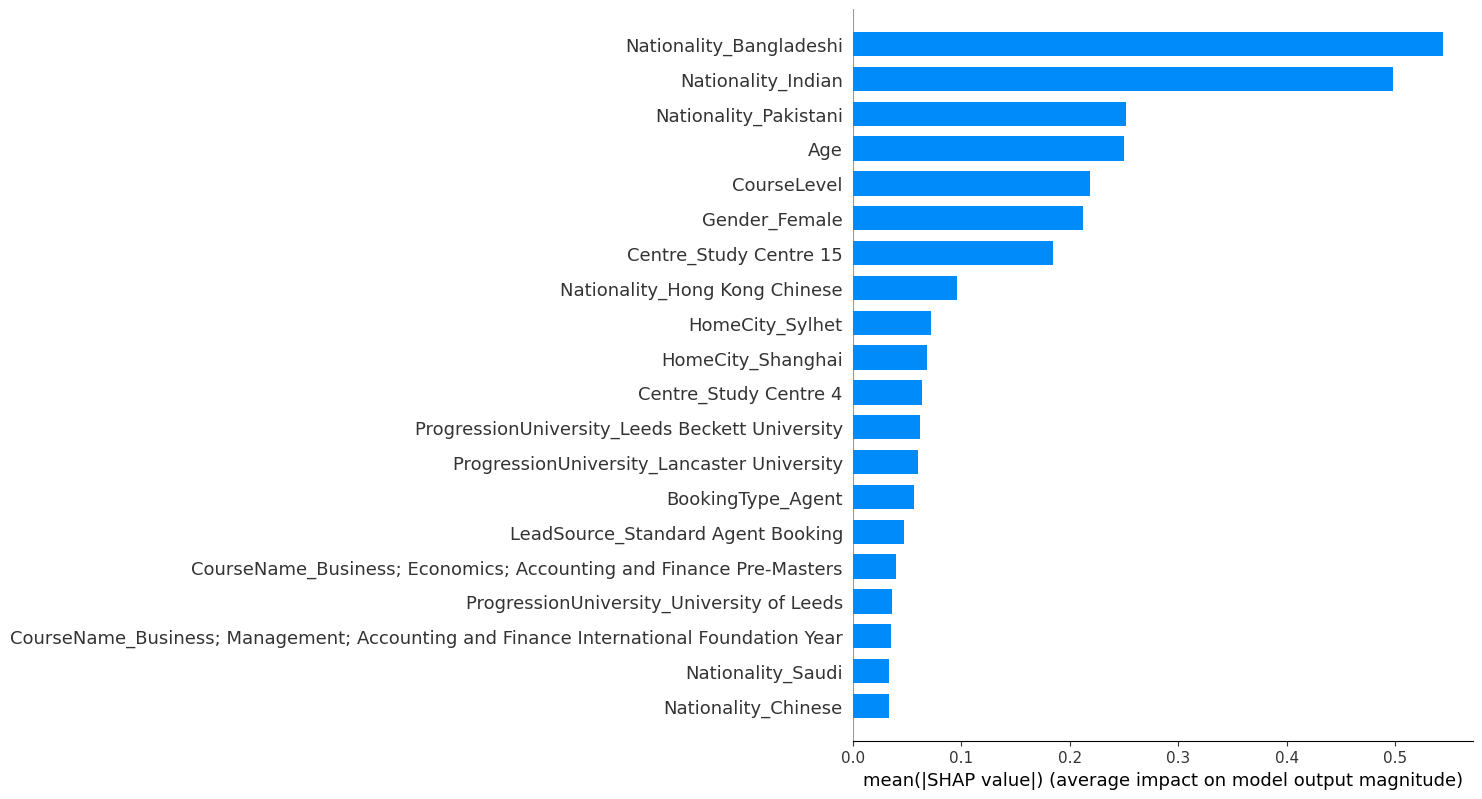

<Figure size 640x480 with 0 Axes>

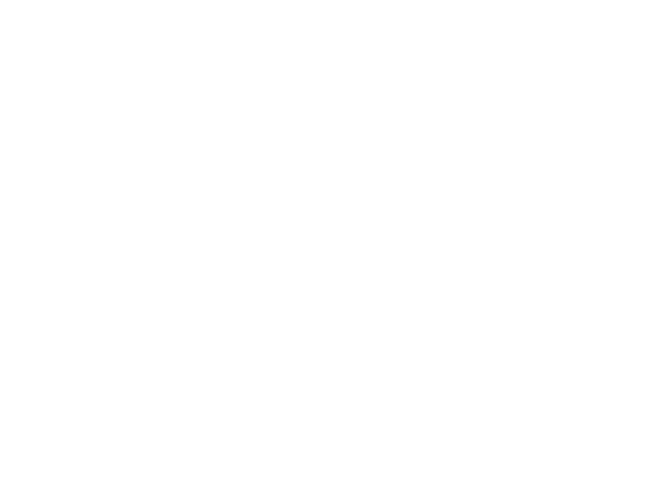

In [ ]:
shap.summary_plot(vals, X_test, plot_type="bar")

plt.savefig("shap_summary1.png", bbox_inches="tight")
plt.show()

display(Image("shap_summary1.png"))

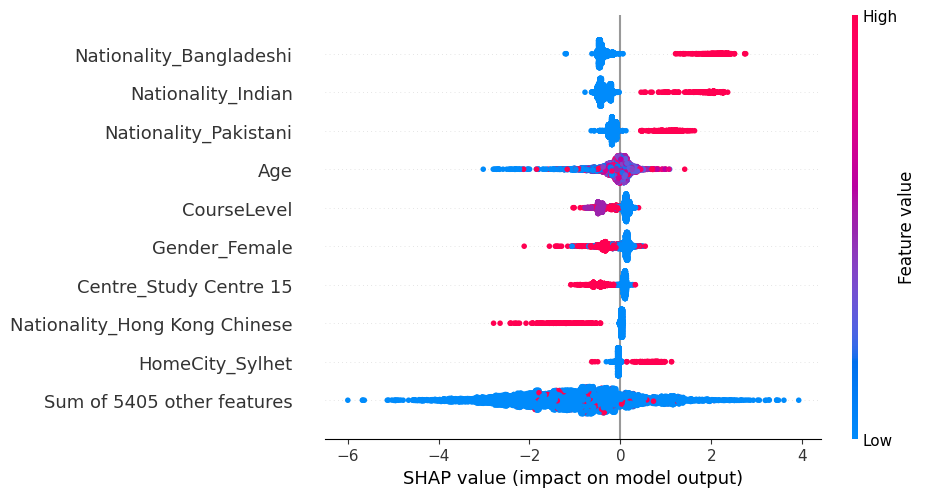

<Figure size 640x480 with 0 Axes>

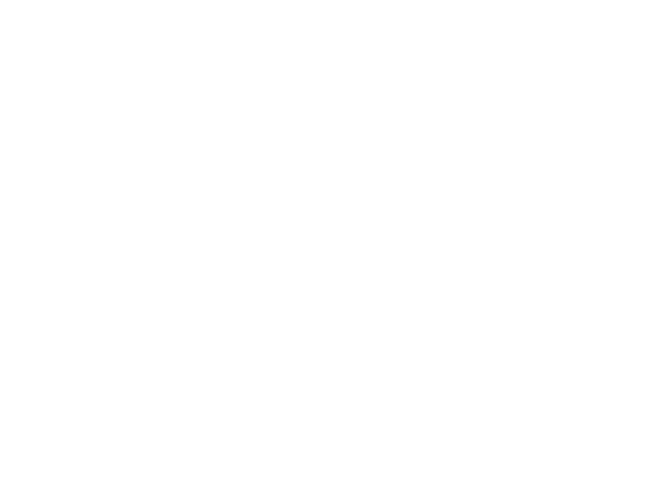

In [ ]:
shap.plots.beeswarm(vals)
plt.savefig("shap_beeswarm1.png", bbox_inches="tight")
plt.show()

display(Image("shap_beeswarm1.png"))

**Observations on feature importance**

How to 'read' this plot:


*   Positive SHAP Values, to the right of 0 on the x-axis: These feature values increase the probability of the target outcome (dropout).
*   Negative SHAP Values (left side of 0): These feature values decrease the probability of dropout (that is, they contribute to student retention).
*   Colour indicates the feature value - for most of them in the plot, the feature is binary (0 or 1) as a result of one-hot encoding. Hence, only two shades: red (1) and blue (0)

What we can see is that demographic factors - such as nationality and gender - are influencing the target variable. In particular:

*   The long red tails to the right for nationality values Bangladeshi, Indian, and Pakistani indicate that students with these nationalities are at higher risk of drop-out
* For female students, there are red dots slightly to the left of the center line, suggesting that being female has some effect on reducing the likelihood of dropping out.
*  There is a blue tail extending left for age, suggesting that younger students are at less risk of drop out

Alongside that, studying at Study Centre 15 seems to highten the risk.

Create neural network model

In [ ]:
epochs = 20
patience = 5
batch_size = 128

In [ ]:
#Create baseline neural network
baseline_neural_1, history_baseline_neural_1 = create_baseline_neural(X_train, y_train, X_val, y_val, epochs = epochs, patience=patience, batch_size=batch_size, model_name='baseline_neural_1')

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.9061 - pr_auc: 0.5333 - val_loss: 0.5638 - val_pr_auc: 0.5702 - learning_rate: 5.0000e-04
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7767 - pr_auc: 0.6085 - val_loss: 0.5318 - val_pr_auc: 0.6373 - learning_rate: 5.0000e-04
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7246 - pr_auc: 0.6426 - val_loss: 0.3196 - val_pr_auc: 0.6538 - learning_rate: 5.0000e-04
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7123 - pr_auc: 0.6551 - val_loss: 0.4324 - val_pr_auc: 0.6444 - learning_rate: 5.0000e-04
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6930 - pr_auc: 0.6741 - val_loss: 0.4200 - val_pr_auc: 0.6303 - learning_rate: 5.0000e-04
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6795 - pr_auc: 0.6839 - val_loss: 0.3995 - val_pr_auc: 0.6167 - learning_rate: 5.0000e-04
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6617 - pr_auc: 0.6934 - 

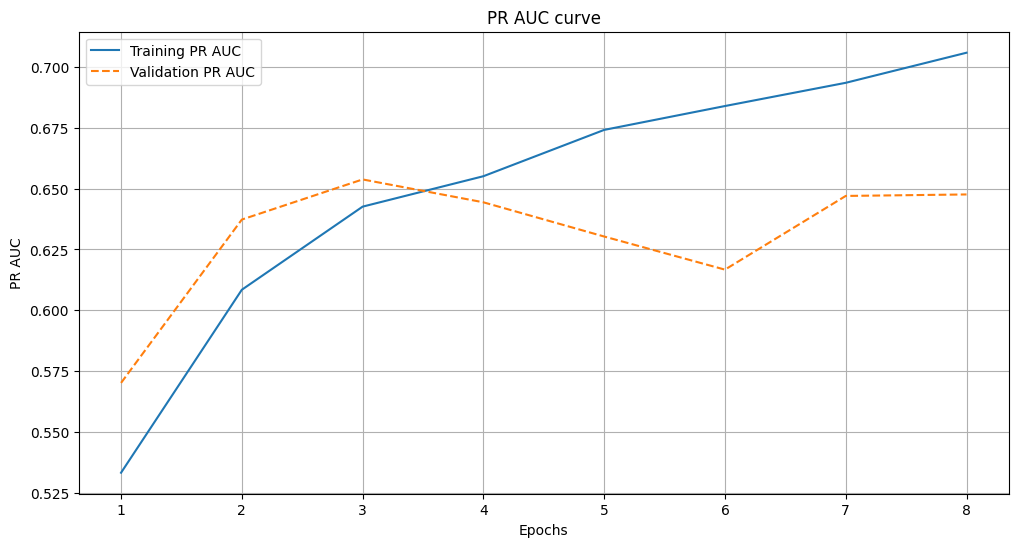

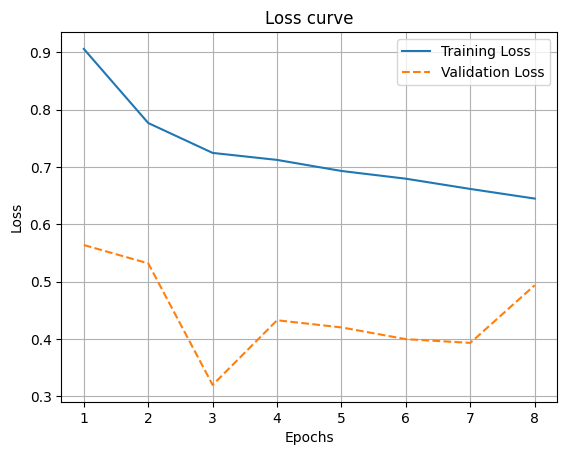

In [ ]:
epochs = len(history_baseline_neural_1.history['pr_auc']) #Handles early stopping
plt = plot_training_history(history_baseline_neural_1, epochs=epochs)

plt.savefig("hist_baseline_neural_1", bbox_inches="tight")
plt.show()


In [ ]:
#Evaluate baseline model & display results
model_performance = []
cm_baseline_neural_1, metrics_baseline_neural_1, PR_baseline_neural_1= evaluate_model(model = baseline_neural_1, X_test=X_test, y_test=y_test)

model_performance.append(metrics_baseline_neural_1)
ev_baseline_neural_1 = pd.DataFrame(model_performance)

display(ev_baseline_neural_1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,Keras_Neural_Net,0.890064,0.624688,0.667111,0.645203,0.660321


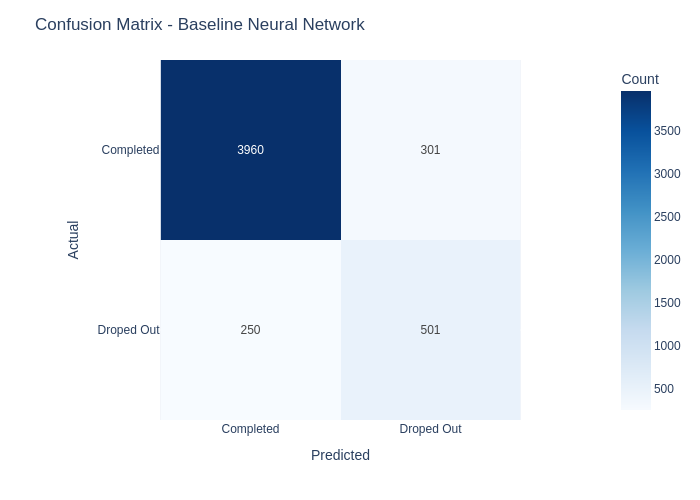

In [ ]:
#Display Confusion Matrix
labels=['Completed', 'Droped Out']
fig = px.imshow(
    cm_baseline_neural_1,
    text_auto=True,
    x=labels,
    y=labels,
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    color_continuous_scale='Blues'
)

fig.update_layout(
    title="Confusion Matrix - Baseline Neural Network",
    xaxis_title="Predicted",
    yaxis_title="Actual"
)

fig.write_image("cm_baseline_neural.png")
display(Image("cm_baseline_neural.png"))

In [ ]:
#HP tune the neural network
hp_neural_1_builder = partial(model_builder, input_dim = X_train.shape[1])
best_hp_neural_1, best_params_hp_neural_1 = hp_neural_search(hp_neural_1_builder, X_train, y_train, X_val, y_val, epochs, batch_size, dir ='student drop out', proj_name = 'Stage1')

Trial 10 Complete [00h 00m 16s]
val_pr_auc: 0.6602924466133118

Best val_pr_auc So Far: 0.6655659675598145
Total elapsed time: 00h 02m 13s
Epoch 1/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.9473 - pr_auc: 0.5191 - val_loss: 0.4040 - val_pr_auc: 0.6145
Epoch 2/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7718 - pr_auc: 0.6001 - val_loss: 0.4080 - val_pr_auc: 0.6410
Epoch 3/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6931 - pr_auc: 0.6493 - val_loss: 0.3310 - val_pr_auc: 0.6533
Epoch 4/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6474 - pr_auc: 0.6759 - val_loss: 0.3024 - val_pr_auc: 0.6475
Epoch 5/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6285 - pr_auc: 0.6828 - val_loss: 0.3305 - val_pr_auc: 0.6525
Epoch 6/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6083 - pr_auc: 0.6883 - val_loss: 0.6383 - val_pr_auc: 0.6268
Epoch 7/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5914 - pr_auc: 0.7003 - val_loss: 0.3766 - val_pr_auc: 0.6392

In [ ]:
n_best_units_layer1 = best_params_hp_neural_1.get('units_1')
n_best_units_layer2 = best_params_hp_neural_1.get('units_2')
best_optimizer = best_params_hp_neural_1.get('optimizer')
best_activation_function_layer1 = best_params_hp_neural_1.get('activation_1')
best_activation_function_layer2 = best_params_hp_neural_1.get('activation_2')

print(f"The best number of units for layer 1 is: {n_best_units_layer1}")
print(f"The best number of units for layer 2 is: {n_best_units_layer2}")
print(f"The best optimizer is: {best_optimizer}")
print(f"The best activation function for layer 1 is: {best_activation_function_layer1}")
print(f"The best activation function for layer 2 is: {best_activation_function_layer2}")

The best number of units for layer 1 is: 32
The best number of units for layer 2 is: 32
The best optimizer is: Adam
The best activation function for layer 1 is: relu
The best activation function for layer 2 is: elu


In [ ]:
#Evaluate the model
model_performance = []

cm_hp_neural_1, metrics_hp_neural_1, PR_hp_neural_1 = evaluate_model(model = best_hp_neural_1, X_test=X_test, y_test=y_test)

model_performance.append(metrics_hp_neural_1)
ev_hp_neural_1 = pd.DataFrame(model_performance)

print(PR_hp_neural_1)
display(ev_hp_neural_1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(array([0.14984038, 0.14987029, 0.1499002 , ..., 0.5       , 0.        ,
       1.        ]), array([1.        , 1.        , 1.        , ..., 0.00133156, 0.        ,
       0.        ]))


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,Keras_Neural_Net,0.883679,0.597902,0.683089,0.637663,0.647394


In [ ]:
#Compare the models
compare_performance(ev_baseline_neural_1, ev_hp_neural_1)

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.890064,0.883679,-0.006385,0.624688,0.597902,-0.026786,0.667111,0.683089,0.015979,0.645203,0.637663,-0.00754,0.660321,0.647394,-0.012927


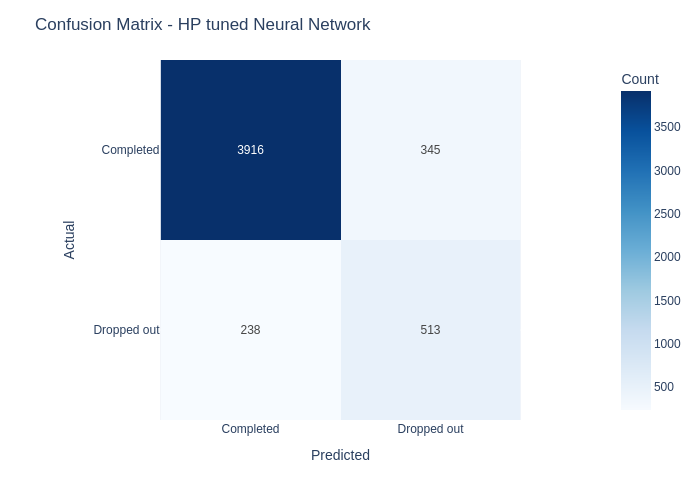

In [ ]:
#Display Confusion Matrix
labels=['Completed', 'Dropped out']
fig = px.imshow(
    cm_hp_neural_1,
    text_auto=True,
    x=labels,
    y=labels,
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    color_continuous_scale='Blues'
)

fig.update_layout(
    title="Confusion Matrix - HP tuned Neural Network",
    xaxis_title="Predicted",
    yaxis_title="Actual"
)

fig.write_image("cm_hp_tuned_neural.png")
display(Image("cm_hp_tuned_neural.png"))

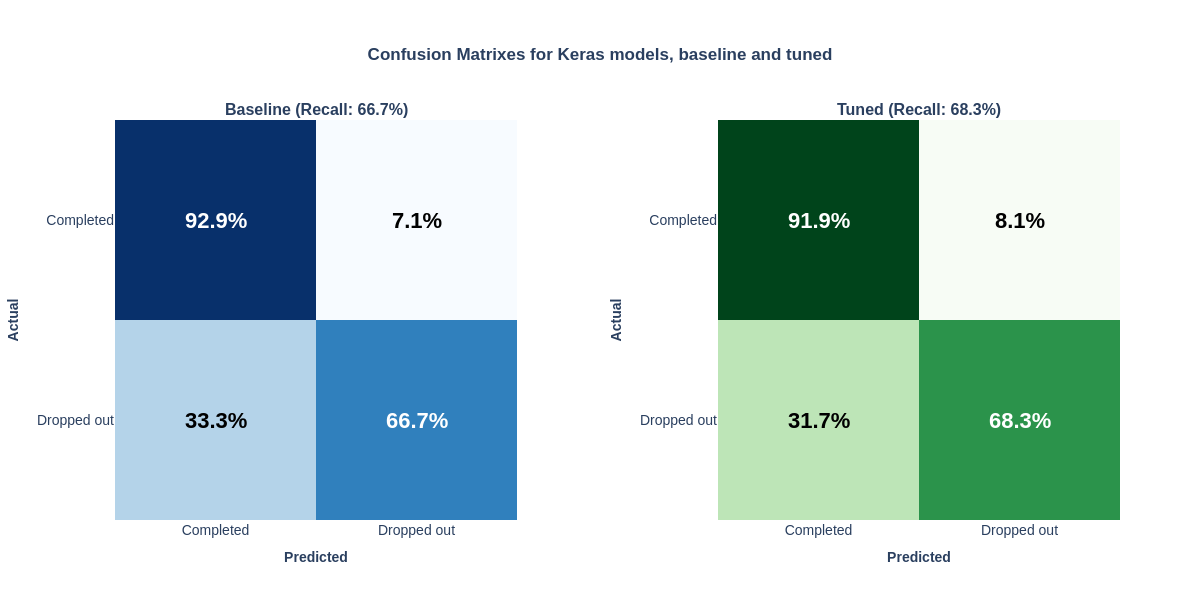

In [ ]:
#Compare the two Confusion Matrixes - Keras before and after hp tuning
fig = compare_cms(cm_baseline_neural_1, cm_hp_neural_1, name_left="Baseline", name_right="Tuned", title = 'Confusion Matrixes for Keras models, baseline and tuned')

fig.write_image("cms_keras_bf_aft.png")
display(Image("cms_keras_bf_aft.png"))

# Stage 2 data

In [ ]:
data2.sample()

,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Centre
24549,2651976,Agent,Standard Agent Booking,NaN,5/7/2001,Male,Indian,Punjab,Ferozepur; Punjab,International Year One,International Year One: Business (ICAS),True,No,BA (Hons) International Business,Teesside University,0.0,148.0,Study Centre 19


In [ ]:
data2.shape

(25059, 18)

**Stage 2: Pre-processing**




In [ ]:
#Convert target variable - CompletedCourse - to a binary value
data2['CompletedCourse'] = np.where(data2['CompletedCourse'].str.lower() == 'yes', 0, 1)

In [ ]:
#Convert 'IsFirstIntake' from Boolean to binary
data2['IsFirstIntake'] = np.where(data2['IsFirstIntake'] == 'yes', 1, 0)

In [ ]:
#Convert date of birth to age
data2['Age'] = (pd.to_datetime('today') - pd.to_datetime(data2['DateofBirth'], dayfirst=True)).dt.days // 365
data2 = data2.drop(columns = ['DateofBirth'])

In [ ]:
#Drop 'LeanerCode'
data2 = data2.drop(columns=['LearnerCode'])

#Remove features withg high cardinality
cat_columns2 = ['Centre', 'BookingType', 'LeadSource',
       'DiscountType', 'Gender', 'Nationality', 'HomeState',
       'HomeCity', 'CourseLevel', 'CourseName','ProgressionDegree', 'ProgressionUniversity']

data2, cat_columns2 = remove_high_cardinality(benchmark = 200, data = data2, cat_columns = cat_columns2)

#Remove columns with >50% missing data
data2, cat_columns2 = remove_high_NA(benchmark = 0.5, data = data2, cat_columns = cat_columns2)

Dropped: 'HomeState'
Dropped: 'ProgressionDegree'
Dropped: 'DiscountType'


In [ ]:
#Identify ordinal data
print(data2['CourseLevel'].value_counts())

CourseLevel
Foundation                14666
Pre-Masters                5905
International Year One     4441
International Year Two       47
Name: count, dtype: int64


In [ ]:
#Ordinaly encode CourseLevel data
course_order = ['Foundation', 'Pre-Masters', 'International Year One', 'International Year Two']
ordinal_encoder = OrdinalEncoder(categories=[course_order])

data2['CourseLevel'] = ordinal_encoder.fit_transform(data2[['CourseLevel']]).astype(int)

if 'CourseLevel' in cat_columns2:
    cat_columns2.remove('CourseLevel')

In [ ]:
#Identify any missing values
missing_counts = data2.isnull().sum()
features_missing = missing_counts[missing_counts > 0]

missing_summary = pd.DataFrame({
    'missing_count': features_missing,
    'missing_pct': features_missing / len(data2) * 100
})

missing_summary

,missing_count,missing_pct
HomeCity,3448,13.759528
AuthorisedAbsenceCount,208,0.830041
UnauthorisedAbsenceCount,208,0.830041


In [ ]:
#Check if there is evidence that null can be read as 0
n_count0_auth_absence = (data2['AuthorisedAbsenceCount'] == 0).sum()
print(f"There are {n_count0_auth_absence} rows with 0 in the authorised absence column")

n_count0_unauth_absence = (data2['UnauthorisedAbsenceCount'] == 0).sum()
print(f"There are {n_count0_unauth_absence} rows with 0 in the unauthorised absence column")

There are 11203 rows with 0 in the authorised absence column
There are 499 rows with 0 in the unauthorised absence column


In [ ]:
#Impute HomeCity with mode from nationality
data2 = impute_home_city(data2)

In [ ]:
#Remove rows with missing values in the two absence count columns
data2 = data2.dropna(subset=['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount'], how='any')

In [ ]:
#Perform one-hot encoding and train_test split
y2 = data2['CompletedCourse']
X2 = data2.drop(columns=['CompletedCourse'])

In [ ]:
preprocessor2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_columns2)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor2.set_output(transform="pandas") #To retain recognisable column names

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Centre', 'BookingType', 'LeadSource',
                                  'Gender', 'Nationality', 'HomeCity',
                                  'CourseName', 'ProgressionUniversity'])],
                  verbose_feature_names_out=False)

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, stratify = y2, random_state = seed)

X_train2 = preprocessor2.fit_transform(X_train2)
X_test2 = preprocessor2.transform(X_test2)

In [ ]:
X_train2, X_val2, y_train2, y_val2 = train_test_split(X_train2, y_train2, test_size = 0.1, stratify = y_train2, random_state=seed)

Create baseline models - for XGBoost

In [ ]:
baseline_xgb_2 = create_baseline_xgb(X_train2, y_train2, X_val2, y_val2)

In [ ]:
#Evaluate performance
model_performance = []

cm_baseline_xgb_2, metrics_baseline_xgb_2, PR_baseline_xgb_2 = evaluate_model(model = baseline_xgb_2, X_test=X_test2, y_test=y_test2)
model_performance.append(metrics_baseline_xgb_2)
ev_baseline_xgb_2 = pd.DataFrame(model_performance)

display(ev_baseline_xgb_2)

,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,XGBClassifier,0.911889,0.759124,0.576177,0.655118,0.730003


In [ ]:
#Create baseline neural model
baseline_neural_2, history_baseline_neural_2 = create_baseline_neural(X_train2, y_train2, X_val2, y_val2, epochs = epochs, patience=patience, batch_size=batch_size, model_name='baseline_neural_2')

Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.8482 - pr_auc: 0.5407 - val_loss: 0.3834 - val_pr_auc: 0.5067 - learning_rate: 5.0000e-04
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7063 - pr_auc: 0.6326 - val_loss: 0.3115 - val_pr_auc: 0.5889 - learning_rate: 5.0000e-04
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6644 - pr_auc: 0.6594 - val_loss: 0.2878 - val_pr_auc: 0.6218 - learning_rate: 5.0000e-04
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6591 - pr_auc: 0.6601 - val_loss: 0.2856 - val_pr_auc: 0.6622 - learning_rate: 5.0000e-04
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6360 - pr_auc: 0.6878 - val_loss: 0.2857 - val_pr_auc: 0.6889 - learning_rate: 5.0000e-04
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6328 - pr_auc: 0.6935 - val_loss: 0.2940 - val_pr_auc: 0.6872 - learning_rate: 5.0000e-04
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6168 - pr_auc: 0.7119 - val_loss

In [ ]:
#Evaluate performance
model_performance = []
cm_baseline_neural_2, metrics_baseline_neural_2, PR_baseline_neural_2 = evaluate_model(model = baseline_neural_2, X_test=X_test2, y_test=y_test2)

model_performance.append(metrics_baseline_neural_2)
ev_baseline_neural_2 = pd.DataFrame(model_performance)

display(ev_baseline_neural_2)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,Keras_Neural_Net,0.859384,0.510044,0.808864,0.625603,0.718002


In [ ]:
#Compare performance of the baseline models - Stage1 Vs Stage2
#XGBoost
compare_performance(ev_baseline_xgb_1, ev_baseline_xgb_2)

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.895052,0.911889,0.016837,0.694974,0.759124,0.06415,0.533955,0.576177,0.042223,0.603916,0.655118,0.051202,0.664705,0.730003,0.065299


In [ ]:
#Neural network
display(compare_performance(ev_baseline_neural_1, ev_baseline_neural_2))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.890064,0.859384,-0.030679,0.624688,0.510044,-0.114645,0.667111,0.808864,0.141754,0.645203,0.625603,-0.0196,0.660321,0.718002,0.05768


None

**Observations on why the results are different**

Both baseline models (XGBoost and Keras) are performing better on the Stage 2 dataset, with both showing gains, on the PR AUC average score, of,respectively, 0.07 & 0.06.

At Stage Two, new data has been introduced on students authorised and unauthorised absences. This in effect moves the data from describing who students are, to how they are behaving. Adding in this data has, maybe unsurprisingly, therefore improved the predictive accuracy of the models.

Carry out hyper-parameter tuning

In [ ]:
#XGBoost model
hp_xgb_2 = hp_xgb(X_train2, y_train2, X_val2, y_val2, 'stage_2')

In [ ]:
#Evaluate the model & compare performance before and after tuning
model_performance = []

cm_hp_xgb_2, metrics_hp_xgb_2, PR_hp_xgb_2 = evaluate_model(model = hp_xgb_2, X_test=X_test2, y_test=y_test2)
model_performance.append(metrics_hp_xgb_2)
ev_hp_xgb_2 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_xgb_2, ev_hp_xgb_2))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.911889,0.892376,-0.019513,0.759124,0.606613,-0.152511,0.576177,0.736842,0.160665,0.655118,0.665416,0.010298,0.730003,0.708016,-0.021988


None

In [ ]:
#Examine shap values from the XGBoost model on Stage Two data
shap.initjs()

# SHAP values
shap_ex2 = shap.TreeExplainer(hp_xgb_2)
vals2 = shap_ex2(X_test2)

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



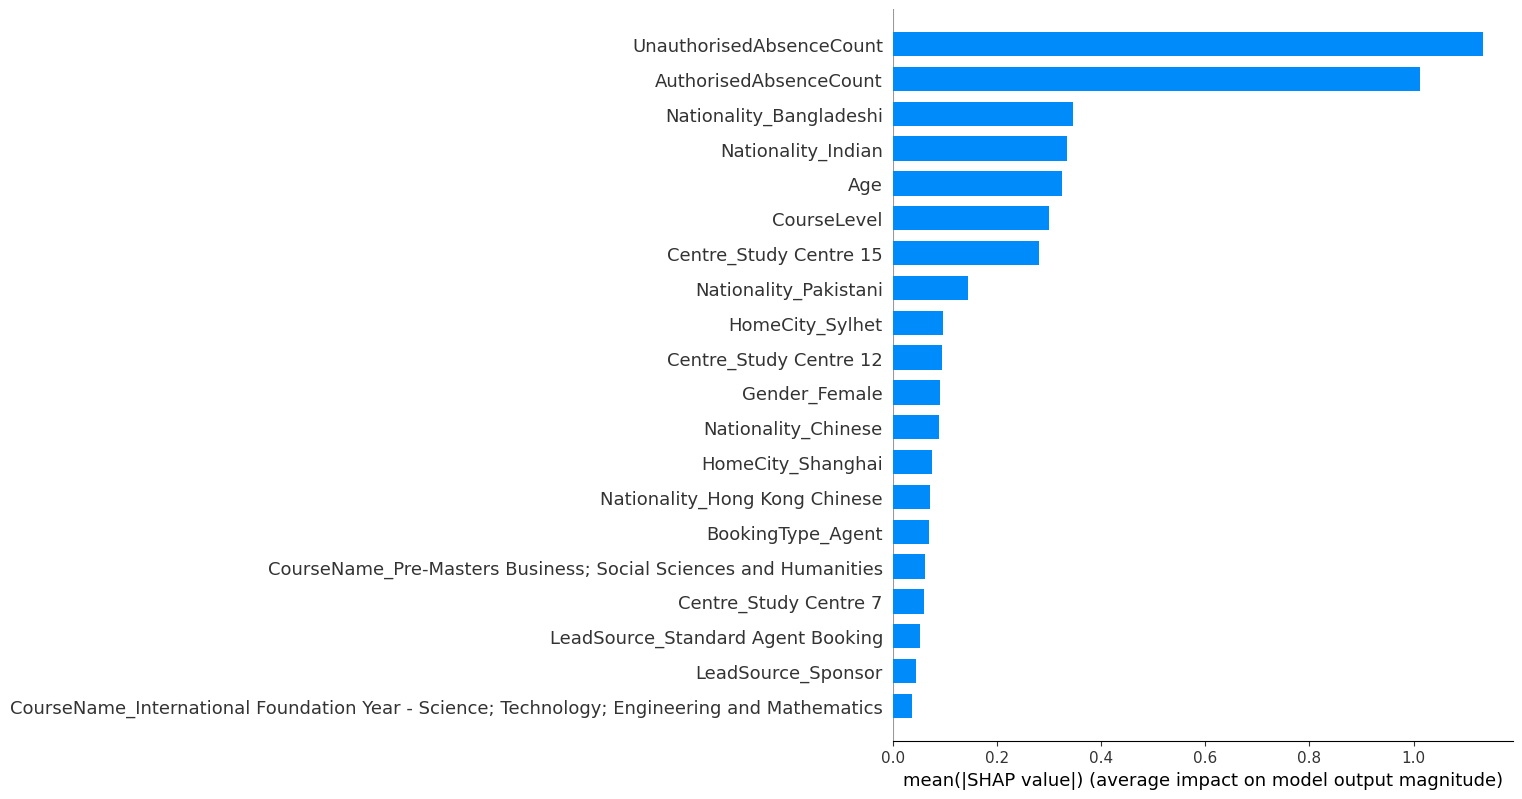

<Figure size 640x480 with 0 Axes>

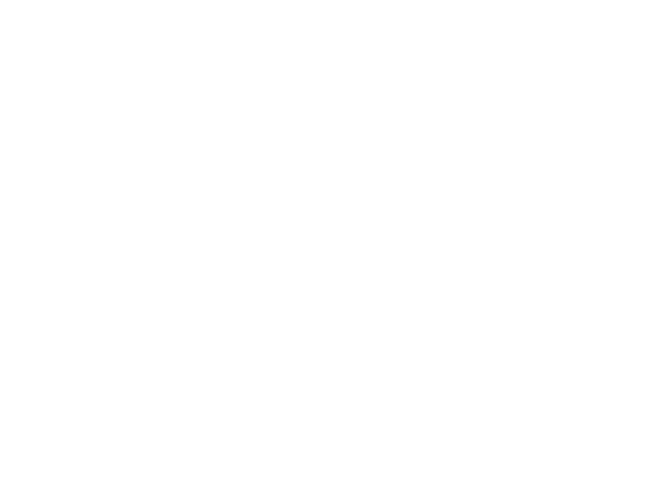

In [ ]:
shap.summary_plot(vals2, X_test2, plot_type="bar")

plt.savefig("summary2.png", bbox_inches="tight")
plt.show()
display(Image("summary2.png"))

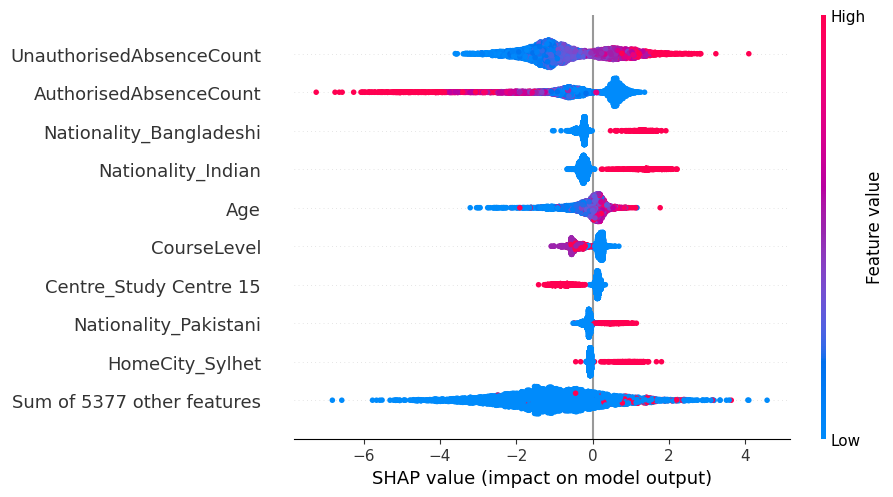

<Figure size 640x480 with 0 Axes>

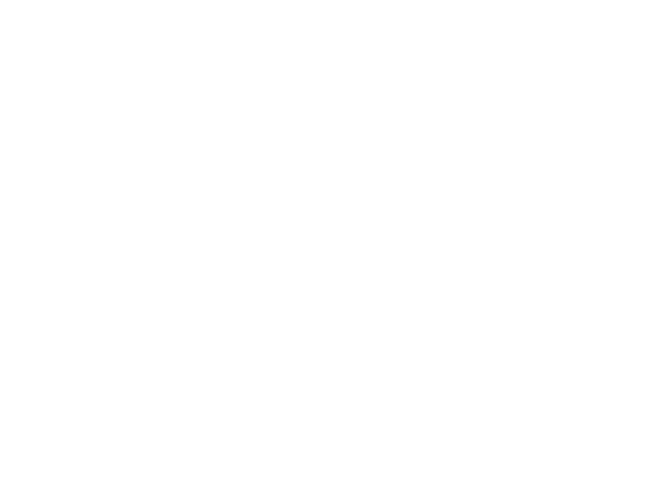

In [ ]:
shap.plots.beeswarm(vals2)
plt.savefig("beeswarm2.png", bbox_inches="tight")
plt.show()

display(Image("beeswarm2.png"))

In [ ]:
#Neural model
hp_neural_2_builder = partial(compile_hp_neural_model, input_dim=X_train2.shape[1])
best_hp_neural_2, best_params_hp_neural_2 = hp_neural_search(hp_neural_2_builder, X_train2, y_train2, X_val2, y_val2, epochs, batch_size, dir ='student drop out', proj_name = 'Stage2')

Trial 10 Complete [00h 00m 14s]
val_pr_auc: 0.7013993263244629

Best val_pr_auc So Far: 0.7013993263244629
Total elapsed time: 00h 02m 17s
Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.7468 - pr_auc: 0.5962 - val_loss: 0.3109 - val_pr_auc: 0.6427
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6611 - pr_auc: 0.6651 - val_loss: 0.3022 - val_pr_auc: 0.6459
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6333 - pr_auc: 0.6867 - val_loss: 0.2928 - val_pr_auc: 0.6731
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6155 - pr_auc: 0.6944 - val_loss: 0.4311 - val_pr_auc: 0.6409
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5933 - pr_auc: 0.7155 - val_loss: 0.4518 - val_pr_auc: 0.6114
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5815 - pr_auc: 0.7237 - val_loss: 0.3312 - val_pr_auc: 0.6779
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5729 - pr_auc: 0.7237 - val_loss: 0.4561 - val_pr_auc: 0.6797

In [ ]:
#Evaluate the model & compare performance before and after tuning
model_performance = []

cm_hp_neural_2, metrics_hp_neural_2, PR_hp_neural_2 = evaluate_model(model = best_hp_neural_2, X_test=X_test2, y_test=y_test2)

model_performance.append(metrics_hp_neural_2)
ev_hp_neural_2 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_neural_2, ev_hp_neural_2))

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.859384,0.878696,0.019312,0.510044,0.559919,0.049876,0.808864,0.770083,-0.038781,0.625603,0.648397,0.022794,0.718002,0.702686,-0.015316


None

**Commment on performance improvement**

On the Stage Two datset, but hp tuned models are performing less well, but by a small amount of ~ -0.02. This contrasts with the gains in performance that we saw through adding in new data (the comparison between Stage One performance and Stage Two.)

Looking at the shap plots for the XGBoost model, the two most important predictive features are now unauthorised and authorised absence. On the former, the relationship between it and dropout looks very linear - the higher the number of unauthorised drop-outs, the greater the risk.

It is likely that both models find this "rule" instantly with their default settings. Hence, hp tuning is not improving performance.

This suggests that effort is better spent on sourcing additional behavioural data, than performance tuning of existing parameters.

# Stage 3 data

**Stage 3: Pre-processing**






In [ ]:
data3.shape

(25059, 21)

In [ ]:
data3.sample(5)

,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,...,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Centre
21657,2529354,Agent,Standard Agent Booking,NaN,22/12/1997,Female,Chinese,Sanhe county ;HEBEI PROVINCE,LANGFANG CITY,Pre-Masters,...,False,Yes,6.0,6.0,0.0,MSc Occupational and Organizational Psychology,University of Surrey,0.0,0.0,Study Centre 17
576,2612706,Agent,Sponsor,NaN,18/03/2002,Male,Kuwaiti,NaN,NaN,Foundation,...,True,Yes,7.0,7.0,0.0,BSc (Hons) Computer Science with Security and ...,Cardiff University,16.0,78.0,Study Centre 2
1743,2494596,Agent,Standard Agent Booking,NaN,2/2/2002,Female,Hong Kong Chinese,NaN,Shau Kei Wan,Foundation,...,False,Yes,9.0,9.0,0.0,LLB - Law,Durham University,50.0,31.0,Study Centre 4
18074,2614816,Agent,Standard Agent Booking,NaN,12/6/2002,Male,Chinese,NaN,Huhhot,Foundation,...,False,Yes,7.0,7.0,0.0,BA (Hons) Accounting & Financial Management & ...,University of Sheffield International College,0.0,24.0,Study Centre 15
1277,2640544,Agent,Sponsor,Other Scholarships / Bursaries,1/10/2003,Female,Kuwaiti,NaN,Kuwait City,Foundation,...,False,No,9.0,2.0,7.0,BE Engineering (Civil),University College Dublin,13.0,129.0,Study Centre 3


In [ ]:
#Convert target variable - CompletedCourse - to a binary value
data3['CompletedCourse'] = np.where(data3['CompletedCourse'].str.lower() == 'yes', 0, 1)

In [ ]:
#Convert 'IsFirstIntake' from Boolean to binary
data3['IsFirstIntake'] = np.where(data3['IsFirstIntake'] == 'yes', 1, 0)

In [ ]:
#Convert date of birth to age
data3['Age'] = (pd.to_datetime('today') - pd.to_datetime(data3['DateofBirth'], dayfirst=True)).dt.days // 365
data3 = data3.drop(columns = ['DateofBirth'])

In [ ]:
#Examine columns
data3.columns

Index(['LearnerCode', 'BookingType', 'LeadSource', 'DiscountType', 'Gender',
       'Nationality', 'HomeState', 'HomeCity', 'CourseLevel', 'CourseName',
       'IsFirstIntake', 'CompletedCourse', 'AssessedModules', 'PassedModules',
       'FailedModules', 'ProgressionDegree', 'ProgressionUniversity',
       'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'Centre', 'Age'],
      dtype='object')

In [ ]:
#Remove Learner Code
data3 = data3.drop(columns=['LearnerCode'])

#Remove features withg high cardinality
cat_columns3 = ['Centre', 'BookingType', 'LeadSource',
       'DiscountType', 'Gender', 'Nationality', 'HomeState',
       'HomeCity', 'CourseLevel', 'CourseName','ProgressionDegree', 'ProgressionUniversity']

data3, cat_columns3 = remove_high_cardinality(benchmark = 200, data = data3, cat_columns = cat_columns3)

#Remove columns with >50% missing data
data3, cat_columns3 = remove_high_NA(benchmark = 0.5, data = data3, cat_columns = cat_columns3)

Dropped: 'HomeState'
Dropped: 'ProgressionDegree'
Dropped: 'DiscountType'


In [ ]:
#Examine CourseLevel data
data3['CourseLevel'].value_counts()

,count
CourseLevel,
Foundation,14666
Pre-Masters,5905
International Year One,4441
International Year Two,47


In [ ]:
#Ordinaly encode CourseLevel data
course_order = ['Foundation', 'Pre-Masters', 'International Year One', 'International Year Two']
ordinal_encoder = OrdinalEncoder(categories=[course_order])

data3['CourseLevel'] = ordinal_encoder.fit_transform(data3[['CourseLevel']]).astype(int)

if 'CourseLevel' in cat_columns3:
    cat_columns3.remove('CourseLevel')

In [ ]:
#Identify any missing values
missing_counts = data3.isnull().sum()
features_missing = missing_counts[missing_counts > 0]

missing_summary = pd.DataFrame({
    'missing_count': features_missing,
    'missing_pct': features_missing / len(data3) * 100
})

display(missing_summary)


,missing_count,missing_pct
HomeCity,3448,13.759528
AssessedModules,2231,8.902989
PassedModules,2231,8.902989
FailedModules,2231,8.902989
AuthorisedAbsenceCount,208,0.830041
UnauthorisedAbsenceCount,208,0.830041


In [ ]:
#Check if missing values in the Modules columns are signifiers of drop-out
print(data3[data3['AssessedModules'].isna()]['CompletedCourse'].value_counts(normalize=True))
print(data3[data3['PassedModules'].isna()]['CompletedCourse'].value_counts(normalize=True))
print(data3[data3['FailedModules'].isna()]['CompletedCourse'].value_counts(normalize=True))

#All people with missing values are drop outs

CompletedCourse
1    1.0
Name: proportion, dtype: float64
CompletedCourse
1    1.0
Name: proportion, dtype: float64
CompletedCourse
1    1.0
Name: proportion, dtype: float64


In [ ]:
#Create the indicator to indicate missing Module data
data3['Modules_Missing_Flag'] = data3['AssessedModules'].isna().astype(int)

#Fill the actual NAs with a constant, -1
data3[['AssessedModules', 'PassedModules', 'FailedModules']] = data3[['AssessedModules', 'PassedModules', 'FailedModules']].fillna(-1)

In [ ]:
#Impute HomeCity based on mode value from the Nationality column
data3 = impute_home_city(data3)

In [ ]:
#Remove rows with missing values in the two absence count columns
data3 = data3.dropna(subset=['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount'], how='any')

In [ ]:
#Perform one-hot encoding and train_test split
y3 = data3['CompletedCourse']
X3 = data3.drop(columns=['CompletedCourse'])

In [ ]:
preprocessor3 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_columns3)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor3.set_output(transform="pandas") #To retain recognisable column names

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Centre', 'BookingType', 'LeadSource',
                                  'Gender', 'Nationality', 'HomeCity',
                                  'CourseName', 'ProgressionUniversity'])],
                  verbose_feature_names_out=False)

In [ ]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size = 0.2, stratify = y3, random_state = 67)

X_train3 = preprocessor3.fit_transform(X_train3)
X_test3 = preprocessor3.transform(X_test3)

X_train3, X_val3, y_train3, y_val3 = train_test_split(X_train3, y_train3, test_size = 0.1, stratify = y_train3,random_state=seed)

In [ ]:
#Create a baseline XGBoost model on the Stage 3 dataset
baseline_xgb_3 = create_baseline_xgb(X_train3, y_train3, X_val3, y_val3)

In [ ]:
#Evaluate performance
model_performance = []

cm_baseline_xgb_3, metrics_baseline_xgb_3, PR_baseline_xgb_3 = evaluate_model(model = baseline_xgb_3, X_test=X_test3, y_test=y_test3)
model_performance.append(metrics_baseline_xgb_3)
ev_baseline_xgb_3 = pd.DataFrame(model_performance)

display(ev_baseline_xgb_3)


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,XGBClassifier,0.991551,0.98433,0.957064,0.970506,0.996432


In [ ]:
#Create baseline neural network
baseline_neural_3, history_baseline_neural_3 = create_baseline_neural(X_train3, y_train3, X_val3, y_val3, epochs = epochs, patience=patience, batch_size=batch_size, model_name='baseline_neural_3')

Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.3440 - pr_auc: 0.9238 - val_loss: 0.1754 - val_pr_auc: 0.9440 - learning_rate: 5.0000e-04
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1538 - pr_auc: 0.9732 - val_loss: 0.0740 - val_pr_auc: 0.9748 - learning_rate: 5.0000e-04
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1327 - pr_auc: 0.9747 - val_loss: 0.0585 - val_pr_auc: 0.9774 - learning_rate: 5.0000e-04
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1151 - pr_auc: 0.9811 - val_loss: 0.1936 - val_pr_auc: 0.9324 - learning_rate: 5.0000e-04
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1163 - pr_auc: 0.9803 - val_loss: 0.0605 - val_pr_auc: 0.9766 - learning_rate: 5.0000e-04
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1132 - pr_auc: 0.9799 - val_loss: 0.0743 - val_pr_auc: 0.9774 - learning_rate: 5.0000e-04
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0956 - pr_auc: 0.9865 - val_loss

In [ ]:
#Evaluate Performance
model_performance = []
cm_baseline_neural_3, metrics_baseline_neural_3, PR_baseline_neural_3 = evaluate_model(model = baseline_neural_3, X_test=X_test3, y_test=y_test3)

model_performance.append(metrics_baseline_neural_3)
ev_baseline_neural_3 = pd.DataFrame(model_performance)

display(ev_baseline_neural_3)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,Keras_Neural_Net,0.988332,0.954795,0.965374,0.960055,0.993267


In [ ]:
#Get shap values
shap.initjs()

# SHAP values
shap_ex3 = shap.TreeExplainer(baseline_xgb_3)
vals3 = shap_ex3(X_test3)

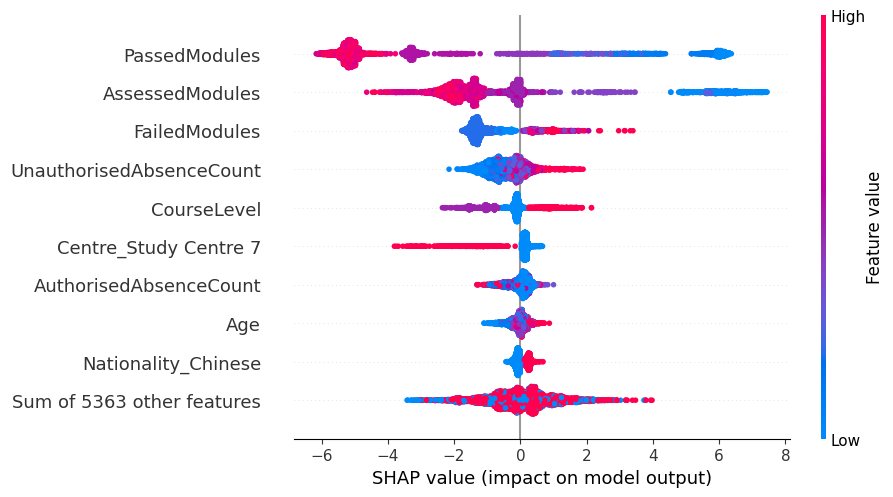

<Figure size 640x480 with 0 Axes>

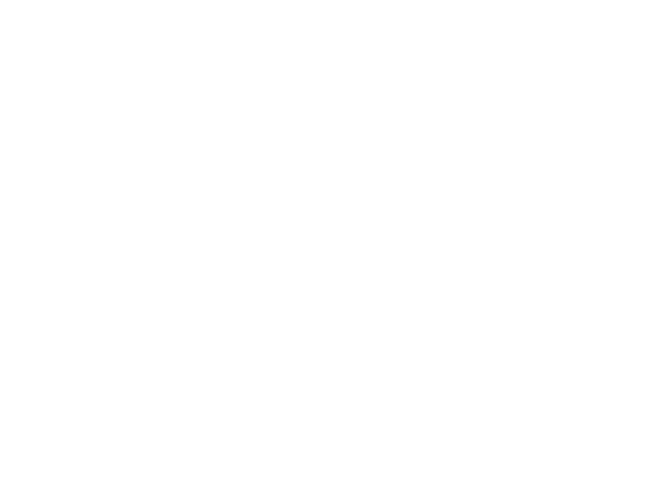

In [ ]:
shap.plots.beeswarm(vals3)
plt.savefig("beeswarm3.png", bbox_inches="tight")
plt.show()

display(Image("beeswarm3.png"))

In [ ]:
#Compare performance of the baseline models - Stage2 Vs Stage3
#XGBoost
display(compare_performance(ev_baseline_xgb_2, ev_baseline_xgb_3))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.911889,0.991551,0.079662,0.759124,0.98433,0.225206,0.576177,0.957064,0.380886,0.655118,0.970506,0.315388,0.730003,0.996432,0.266428


None

In [ ]:
#Neural network
display(compare_performance(ev_baseline_neural_2, ev_baseline_neural_3))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.859384,0.988332,0.128948,0.510044,0.954795,0.444751,0.808864,0.965374,0.15651,0.625603,0.960055,0.334453,0.718002,0.993267,0.275265


None

**Observations on the difference in performance between Stage 2 and Stage 3**

On the stage 3 dataset, both baseline models are performing significantly better on the PR AUC metric, with values approaching 1 - that is, approaching perfect prediction.

This suggests that the data added in at stage three are not signals, but surrogates / proxies for the outcome itself. This is very plausible given what they describe: Number of modules assessed, Number of modules passed, and Number of modules failed.

For example, if a student has 0 modules passed, then it is likely that they will be a drop-out.

This is confirmed by the shap values shown above - the new features at stage three dominate the predictions. The models, at this stage, are not predictive but descriptive.

We should expect very little, if any, improvement from hp tuning ...

Carry out hp tuning

In [ ]:
#XGBoost model
hp_xgb_3 = hp_xgb(X_train3, y_train3, X_val3, y_val3, 'stage_3')

In [ ]:
#Evaluate the model & compare performance before and after tuning
model_performance = []

cm_hp_xgb_3, metrics_hp_xgb_3, PR_hp_xgb_3 = evaluate_model(model = hp_xgb_3, X_test=X_test3, y_test=y_test3)
model_performance.append(metrics_hp_xgb_3)
ev_hp_xgb_3 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_xgb_3, ev_hp_xgb_3))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.991551,0.992557,0.001006,0.98433,0.981716,-0.002615,0.957064,0.966759,0.009695,0.970506,0.97418,0.003674,0.996432,0.99637,-0.000062


None

In [ ]:
#Neural model
hp_neural_3_builder = partial(compile_hp_neural_model, input_dim=X_train3.shape[1])
best_hp_neural_3, best_params_hp_neural_3 = hp_neural_search(hp_neural_3_builder, X_train3, y_train3, X_val3, y_val3, epochs, batch_size, dir ='student drop out', proj_name = 'Stage3')

Trial 10 Complete [00h 00m 15s]
val_pr_auc: 0.9850872755050659

Best val_pr_auc So Far: 0.9864415526390076
Total elapsed time: 00h 02m 16s
Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3255 - pr_auc: 0.9320 - val_loss: 0.1978 - val_pr_auc: 0.9668
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1716 - pr_auc: 0.9833 - val_loss: 0.1200 - val_pr_auc: 0.9713
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1443 - pr_auc: 0.9842 - val_loss: 0.1140 - val_pr_auc: 0.9739
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1279 - pr_auc: 0.9880 - val_loss: 0.0741 - val_pr_auc: 0.9821
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1197 - pr_auc: 0.9877 - val_loss: 0.0520 - val_pr_auc: 0.9837
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1102 - pr_auc: 0.9895 - val_loss: 0.0565 - val_pr_auc: 0.9855
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1005 - pr_auc: 0.9900 - val_loss: 0.0667 - val_pr_auc: 0.9862

In [ ]:
#Evaluate the model & compare performance before and after tuning
model_performance = []

cm_hp_neural_3, metrics_hp_neural_3, PR_hp_neural_3 = evaluate_model(model = best_hp_neural_3, X_test=X_test3, y_test=y_test3)

model_performance.append(metrics_hp_neural_3)
ev_hp_neural_3 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_neural_3, ev_hp_neural_3))

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.988332,0.983303,-0.005029,0.954795,0.913325,-0.04147,0.965374,0.977839,0.012465,0.960055,0.944482,-0.015573,0.993267,0.99188,-0.001387


None

**Observations on improvements**
As expected, the performance of both models is not signifcantly affected by hyper-parameter tuning.

This is designed to find subtle, patterns in "noisy" data. At stage three, our dataset is very loud (and clear) meaning that tuning essentially loses its purpose.

# Supplementary Analysis for the report

Plot PR Areas Under the Curve

In [ ]:
#Mapping for Baseline Models
baseline_data = {
    "Stage 1": {"XGBoost": PR_baseline_xgb_1, "Keras": PR_baseline_neural_1},
    "Stage 2": {"XGBoost": PR_baseline_xgb_2, "Keras": PR_baseline_neural_2},
    "Stage 3": {"XGBoost": PR_baseline_xgb_3, "Keras": PR_baseline_neural_3}
}

#Mapping for Tuned Models
tuned_data = {
    "Stage 1": {"XGBoost": PR_hp_xgb_1, "Keras": PR_hp_neural_1},
    "Stage 2": {"XGBoost": PR_hp_xgb_2, "Keras": PR_hp_neural_2},
    "Stage 3": {"XGBoost": PR_hp_xgb_3, "Keras": PR_hp_neural_3}
}

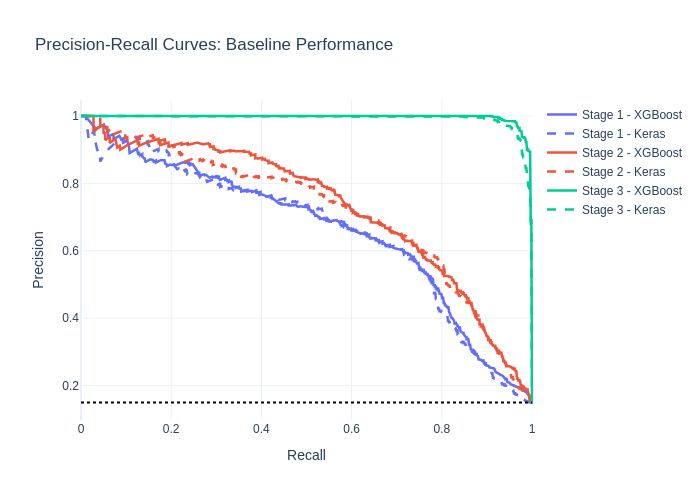

In [ ]:
#Plot baseline models results
fig_baseline = go.Figure()

stage_colors = {"Stage 1": "#636EFA", "Stage 2": "#EF553B", "Stage 3": "#00CC96"}
model_styles = {"XGBoost": "solid", "Keras": "dash"}

for stage, models in baseline_data.items():
    for model_type, pr_tuple in models.items():
        fig_baseline.add_trace(go.Scatter(
            x=pr_tuple[1], # Recalls
            y=pr_tuple[0], # Precisions
            name=f"{stage} - {model_type}",
            mode='lines',
            line=dict(color=stage_colors[stage], dash=model_styles[model_type], width=2.5)
        ))

#Add the 15% drop-out baseline
fig_baseline.add_shape(type="line", x0=0, x1=1, y0=0.15, y1=0.15, line=dict(color="black", dash="dot"))

fig_baseline.update_layout(
    title="Precision-Recall Curves: Baseline Performance",
    xaxis_title="Recall", yaxis_title="Precision",
    template="plotly_white"
)

fig_baseline.write_image("baseline_pr_curves.png")
display(Image("baseline_pr_curves.png"))

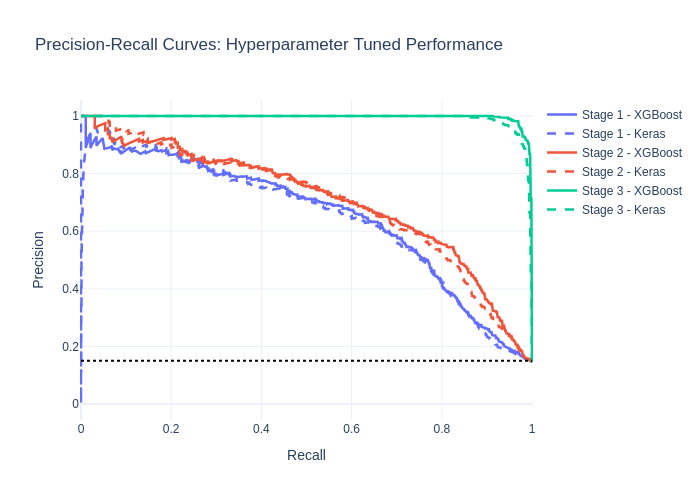

In [ ]:
#Plot HP tuned model results
fig_tuned = go.Figure()

for stage, models in tuned_data.items():
    for model_type, pr_tuple in models.items():
        fig_tuned.add_trace(go.Scatter(
            x=pr_tuple[1], # Recalls
            y=pr_tuple[0], # Precisions
            name=f"{stage} - {model_type}",
            mode='lines',
            line=dict(color=stage_colors[stage], dash=model_styles[model_type], width=2.5)
        ))

# Add the 15% drop-out baseline
fig_tuned.add_shape(type="line", x0=0, x1=1, y0=0.15, y1=0.15, line=dict(color="black", dash="dot"))

fig_tuned.update_layout(
    title="Precision-Recall Curves: Hyperparameter Tuned Performance",
    xaxis_title="Recall", yaxis_title="Precision",
    template="plotly_white"
)


fig_tuned.write_image("tuned_pr_curves.png")
display(Image("tuned_pr_curves.png"))

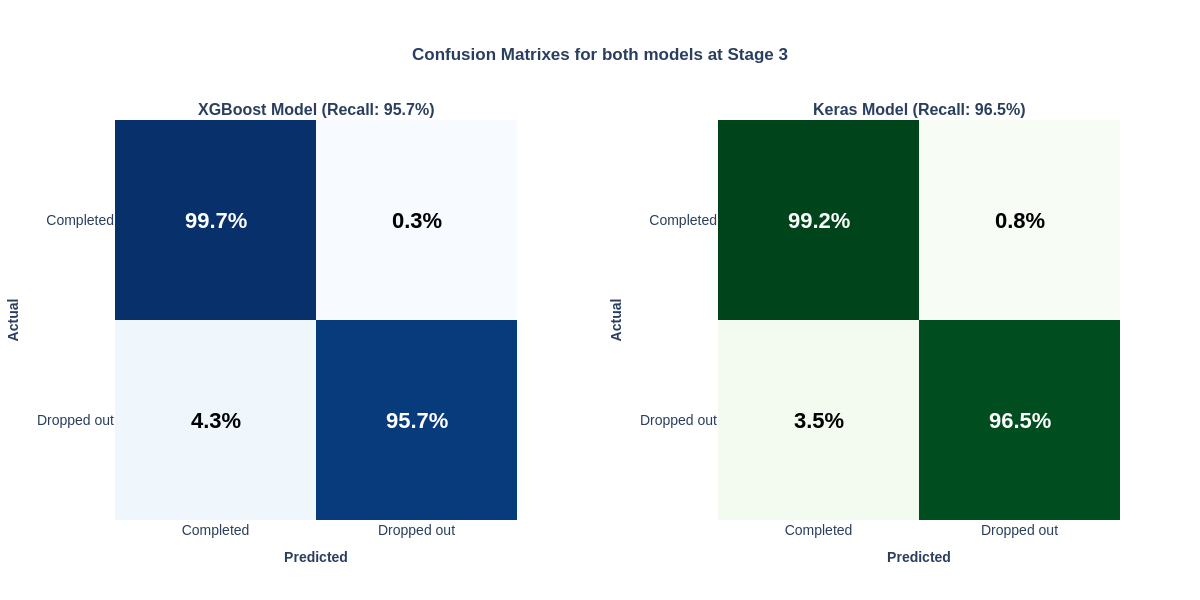

In [ ]:
#CM Matrixes at Stage Three
fig = compare_cms(cm_baseline_xgb_3, cm_baseline_neural_3, name_left="XGBoost Model", name_right="Keras Model", title = 'Confusion Matrixes for both models at Stage 3')
fig.write_image("cms_stage3.png")
display(Image("cms_stage3.png"))